In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

# Make the repository root importable when the notebook is launched from the notebooks folder
cwd = Path.cwd().resolve()
project_root = cwd
if not (project_root / "app").exists():
    project_root = cwd.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)

from app.models.predictor import predict
from app.xai.gradcam import generate_heatmap

TEST_SAMPLES_DIR = (project_root / "test_samples").resolve()

# Sanity check
print(f"Project root: {project_root}")
print(f"Looking for test samples in: {TEST_SAMPLES_DIR}")
print(f"Found {len(list(TEST_SAMPLES_DIR.glob('*.jpg')))} images")

Project root: E:\Medical_AI_Platform
Looking for test samples in: E:\Medical_AI_Platform\test_samples
Found 12 images


Single image demo

Loading model from E:\Medical_AI_Platform\models\brain_tumor_densenet121.pth...
Model loaded and ready on cpu
Prediction result:
  predicted_class: glioma
  confidence: 0.8675
  all_probabilities: {'glioma': 0.8675, 'meningioma': 0.1137, 'notumor': 0.0178, 'pituitary': 0.0009}


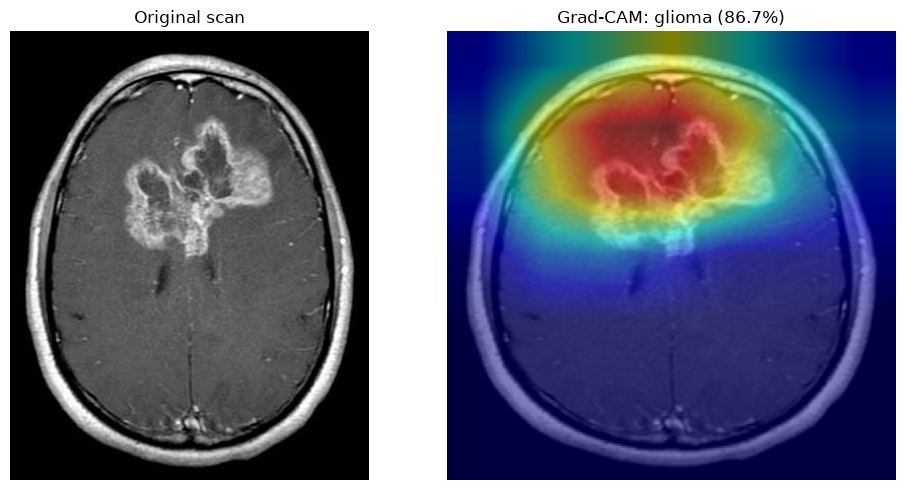

In [2]:
# Pick one glioma sample

# Pick one glioma sample
sample_path = TEST_SAMPLES_DIR / "glioma_1.jpg"

# Run prediction
prediction = predict(sample_path)
print("Prediction result:")
for key, value in prediction.items():
    print(f"  {key}: {value}")

# Generate heatmap
heatmap, cls, conf = generate_heatmap(sample_path)

# Display original and heatmap side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(Image.open(sample_path).convert("RGB"))
axes[0].set_title("Original scan", fontsize=12)
axes[0].axis("off")

axes[1].imshow(heatmap)
axes[1].set_title(f"Grad-CAM: {cls} ({conf:.1%})", fontsize=12)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3. All classes gallery

Now we run the pipeline on multiple samples from every class. This shows how the model attends differently to different tumor types.

For each class, we display 3 samples with their heatmaps.

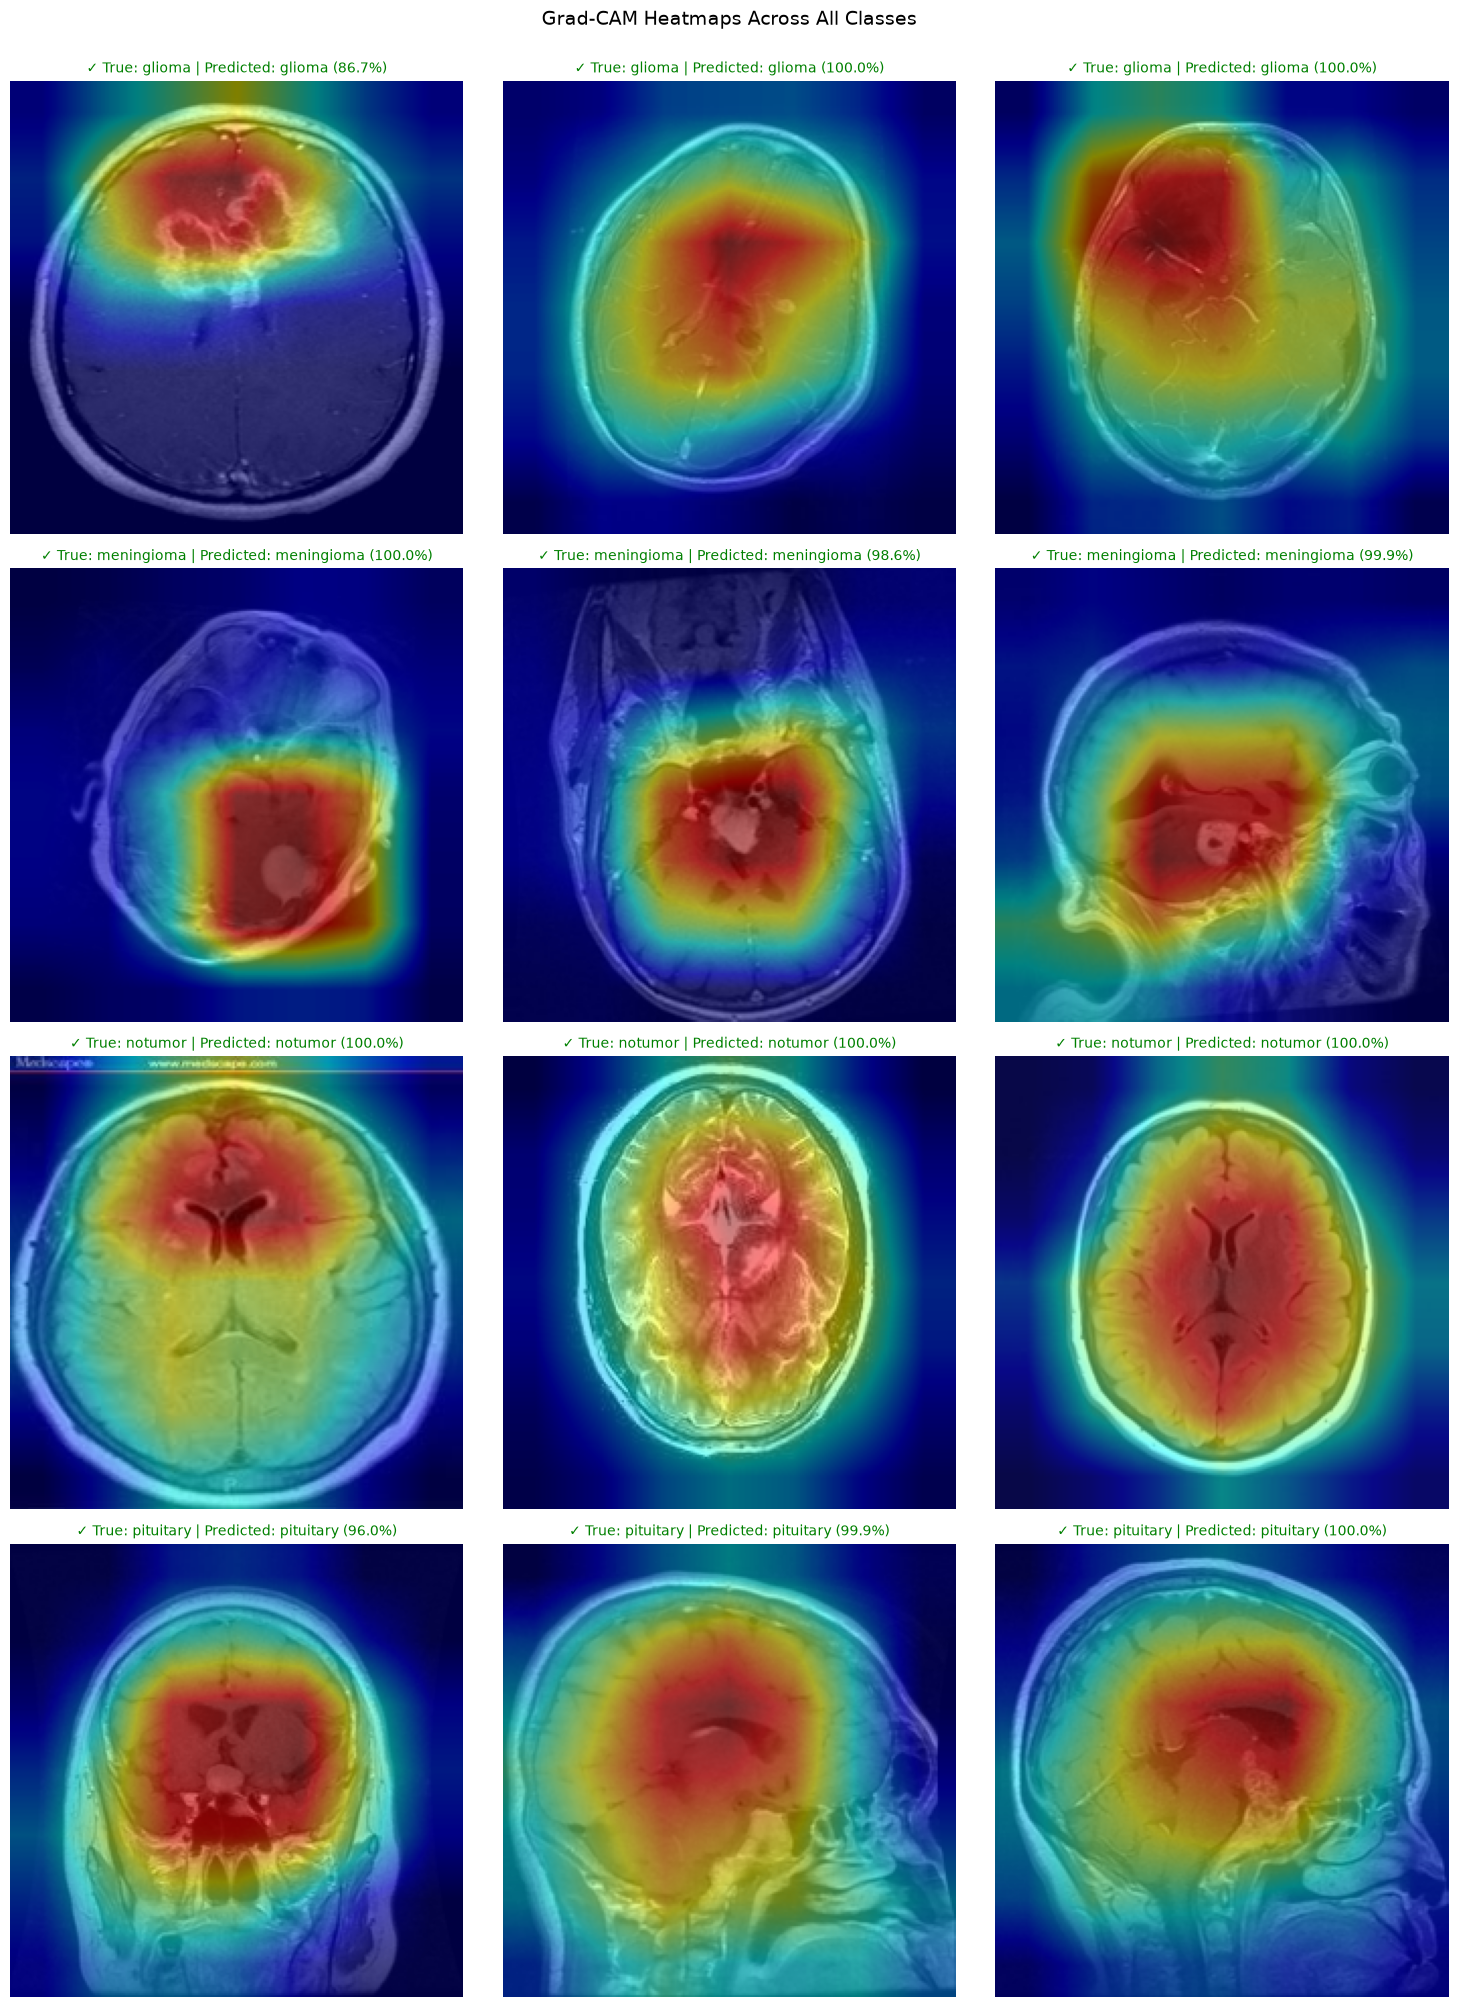

In [3]:
classes = ["glioma", "meningioma", "notumor", "pituitary"]

fig, axes = plt.subplots(len(classes), 3, figsize=(15, 5 * len(classes)))

for row, cls in enumerate(classes):
    # Get all samples for this class
    samples = sorted(TEST_SAMPLES_DIR.glob(f"{cls}_*.jpg"))[:3]

    for col, sample_path in enumerate(samples):
        heatmap, pred_cls, conf = generate_heatmap(sample_path)

        ax = axes[row, col]
        ax.imshow(heatmap)

        # Mark correct predictions in green, wrong in red
        color = "green" if pred_cls == cls else "red"
        symbol = "✓" if pred_cls == cls else "✗"

        title = f"{symbol} True: {cls} | Predicted: {pred_cls} ({conf:.1%})"
        ax.set_title(title, fontsize=10, color=color)
        ax.axis("off")

plt.suptitle("Grad-CAM Heatmaps Across All Classes", fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

## 4. Focus on misclassifications

From Phase 1 test results, glioma had the lowest sensitivity (81.25%). Let's look specifically at what the heatmap shows for glioma samples — are misclassified gliomas being missed because the model attends to the wrong region?

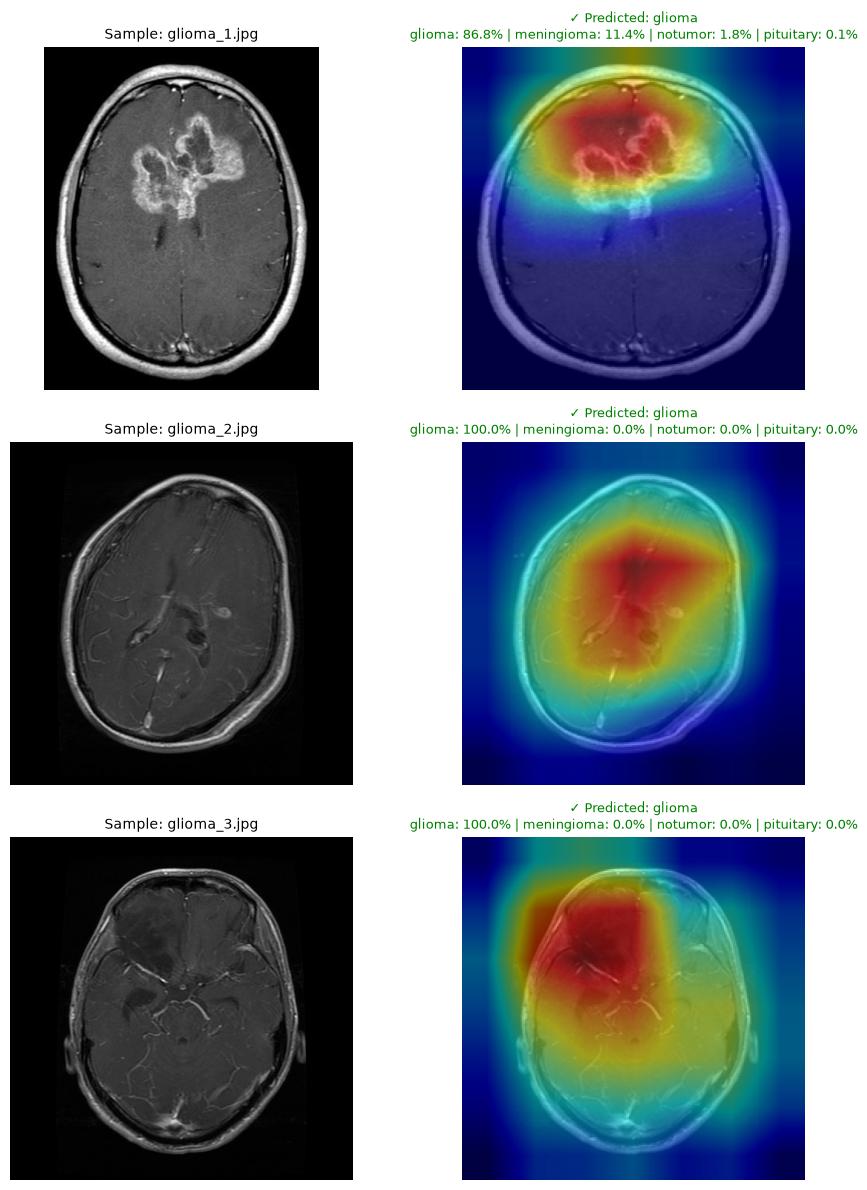

In [4]:
glioma_samples = sorted(TEST_SAMPLES_DIR.glob("glioma_*.jpg"))

fig, axes = plt.subplots(len(glioma_samples), 2, figsize=(10, 4 * len(glioma_samples)))

for i, sample_path in enumerate(glioma_samples):
    prediction = predict(sample_path)
    heatmap, pred_cls, conf = generate_heatmap(sample_path)

    # Left: original scan
    axes[i, 0].imshow(Image.open(sample_path).convert("RGB"))
    axes[i, 0].set_title(f"Sample: {sample_path.name}", fontsize=10)
    axes[i, 0].axis("off")

    # Right: heatmap with all class probabilities
    axes[i, 1].imshow(heatmap)
    prob_text = " | ".join(
        f"{cls}: {p:.1%}"
        for cls, p in prediction["all_probabilities"].items()
    )
    correct = "✓" if pred_cls == "glioma" else "✗"
    color = "green" if pred_cls == "glioma" else "red"
    axes[i, 1].set_title(f"{correct} Predicted: {pred_cls}\n{prob_text}",
                         fontsize=9,
                         color=color)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 5. Analysis and Observations

**Observations from the heatmaps:**

*(Fill in this section based on what you actually see in your visualizations.)*

**Guiding questions to answer:**

1. **Do the heatmaps localize on tumor regions?** In correctly classified samples, is the red/hot area on visible tumor tissue, or on non-relevant regions like edges and background?

2. **What distinguishes successful predictions from failures?** For misclassified gliomas — where does the heatmap focus? Is it looking at something plausible or completely random?

3. **Which class produces the most confident heatmaps?** Some classes may show tight, focused attention while others show diffuse attention.

4. **Are heatmaps consistent within a class?** Compare the three heatmaps for each class — do they highlight similar spatial patterns?

**My observations:**

*(Write 3-4 paragraphs here based on your actual heatmap outputs)*

Example structure:

> Across all four classes, the heatmaps generally localize on brain tissue rather than background, which suggests the model has learned meaningful features rather than dataset artifacts.
> 
> Pituitary tumor predictions show tight focus at the base of the brain, consistent with pituitary anatomy. Meningioma and notumor predictions show broader but still brain-centered attention.
> 
> Glioma predictions show the most variable attention patterns — correctly classified gliomas tend to focus on visible masses, while misclassified ones show diffuse attention or attention on the wrong tissue region. This is consistent with the 81.25% sensitivity reported in Phase 1.
> 
> Overall, the Grad-CAM visualizations support the interpretation that the model uses clinically meaningful features, but glioma classification specifically would benefit from further work — either more training data, focal loss to address the sensitivity gap, or preprocessing to standardize tumor appearance.

## 6. Conclusion

The Grad-CAM pipeline is now integrated into the platform as a reusable module (`app/xai/gradcam.py`). It can be called from any downstream component to provide visual justification for every prediction.

**Modules built in Phase 2:**
- `app.core.config` — centralized settings loaded from `model_metadata.json`
- `app.models.model_loader` — cached model loading with device selection
- `app.models.predictor` — clean prediction API returning class + probabilities
- `app.xai.gradcam` — Grad-CAM heatmap generation

**Ready for downstream integration:**
- Phase 3 will feed the predictions and heatmap findings into an LLM to generate medical reports
- Phase 4 will expose these functions through a REST API
- Phase 5 will store predictions in a database
- Phase 6 will display heatmaps in a web frontend